In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data_mine_and_clustering/drone_cust_locations.csv", sep=";")

display(df.head())

,clientid,x,y
0,1,622.771572,164.857623
1,2,416.357298,630.193634
2,3,292.735020,567.333231
3,4,737.211288,166.225676
4,5,540.475375,682.912298


In [3]:
df.dtypes

clientid      int64
x           float64
y           float64
dtype: object

In [4]:
X = df[["x", "y"]]

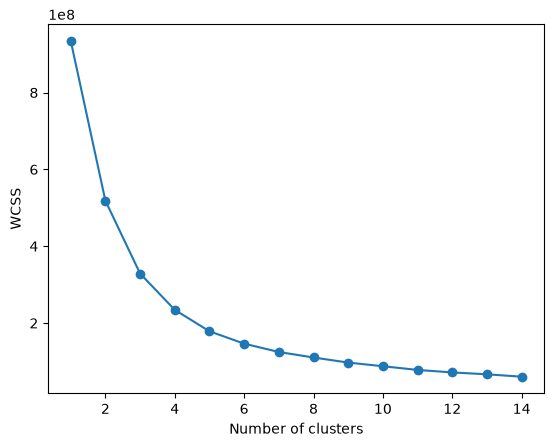

In [5]:
wcss = []
for i in range(1,15):
    model = KMeans(init='random', n_clusters=i, random_state=42).fit(X)
    wcss.append(model.inertia_)
    
plt.plot(range(1,15), wcss, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [8]:
n_clusters_list = [2, 3, 4, 5, 6, 7, 8]

In [9]:
for n_clusters in n_clusters_list:
    model = KMeans(init='random', n_clusters=n_clusters, random_state=42).fit(X)
    labels = model.labels_
    print(f'Silhouette score for k value of {n_clusters}: {silhouette_score(X, labels): .2f}')

Silhouette score for k value of 2:  0.42
Silhouette score for k value of 3:  0.42
Silhouette score for k value of 4:  0.40
Silhouette score for k value of 5:  0.42
Silhouette score for k value of 6:  0.40
Silhouette score for k value of 7:  0.39
Silhouette score for k value of 8:  0.39


Elbow method suggests that the optimal number of clusters is around 3–5. The silhouette scores for k = 2, 3 and 5 are approximately equal (0.42). Based on both methods, k = 5 was selected as the number of clusters.

In [10]:
n_clusters = 5